In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import pandas as pd

In [2]:
# Load accept-reject and hadron data (for base parameterization) 
# accept_reject_base_PATH = './model_test/pgun_uubar_id_mT2_accept_reject_model_test_base_N_1e4.npy'
# accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.72_b0.88_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.88_bC0.88_bB0.88_bH0.88_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.76_b0.84_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.84_bU0.84_bS0.84_bC0.84_bB0.84_bH0.84_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
pgun_accept_reject_base = np.load(accept_reject_base_PATH, mmap_mode = "r")

# fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.72_b0.88_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.88_bC0.88_bB0.88_bH0.88_sigma_0.335_N_1.0e+05_fPrel.npy'
# fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.76_b0.84_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.84_bU0.84_bS0.84_bC0.84_bB0.84_bH0.84_sigma_0.335_N_1.0e+05_fPrel.npy'
# fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_fPrel.npy'
fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_fPrel.npy'
pgun_fPrel_base = np.load(fPrel_base_PATH, mmap_mode = "r")

# filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.72_b0.88_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.88_bC0.88_bB0.88_bH0.88_sigma_0.335_N_1.0e+05_hadrons.npy'
# filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.76_b0.84_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.84_bU0.84_bS0.84_bC0.84_bB0.84_bH0.84_sigma_0.335_N_1.0e+05_hadrons.npy'
# filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
pgun_hadrons_base = np.load(filename_hadrons_base, mmap_mode="r")

# Load the hadron data from the target for comparison
# filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.72_b0.88_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.88_bC0.88_bB0.88_bH0.88_sigma_0.335_N_1.0e+05_hadrons.npy'
# filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.76_b0.84_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.84_bU0.84_bS0.84_bC0.84_bB0.84_bH0.84_sigma_0.335_N_1.0e+05_hadrons.npy'
# filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0.1_aU-0.1_aS0_aC0_aB0_aH0.97_bD1.08_bU0.88_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0.15_aU0_aS0_aC0_aB0_aH0.97_bD0.68_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0.04_aU0.04_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
pgun_hadrons_target = np.load(filename_hadrons_target, mmap_mode="r")

# accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.72_b0.88_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.88_bC0.88_bB0.88_bH0.88_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.76_b0.84_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.84_bU0.84_bS0.84_bC0.84_bB0.84_bH0.84_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0.15_aU0_aS0_aC0_aB0_aH0.97_bD0.68_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0.04_aU0.04_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
pgun_accept_reject_target = np.load(accept_reject_target_PATH, mmap_mode = "r")

In [3]:
# Check the shapes
print("Accepted and rejected z data shape:", pgun_accept_reject_base.shape)
print("fPrel data shape:", pgun_fPrel_base.shape)
print("Hadron data shape:", pgun_hadrons_base.shape)
# print(pgun_accept_reject_base[0,0])
# print(pgun_hadrons_base[0])

nevents = 1000
pgun_accept_reject_base = pgun_accept_reject_base[:nevents]
pgun_fPrel_base = pgun_fPrel_base[:nevents]
pgun_hadrons_base = pgun_hadrons_base[:nevents]
pgun_accept_reject_target = pgun_accept_reject_target[:nevents]

Accepted and rejected z data shape: (100000, 250, 103)
fPrel data shape: (100000, 250, 100)
Hadron data shape: (100000, 75, 6)


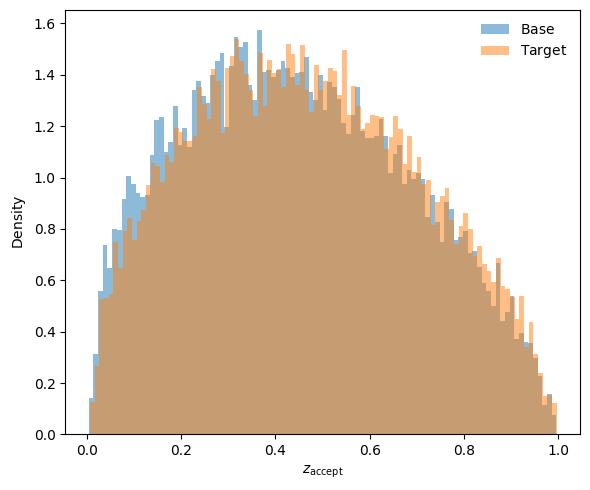

In [4]:
# Histrogram accepted z-values across all events
fig, ax = plt.subplots(1,1,figsize=(6,5))
ax.hist(pgun_accept_reject_target[:,:,3][pgun_accept_reject_target[:,:,3] > 0.0], 100, alpha = 0.5, density = True, label = r"$\mathrm{Base}$")
ax.hist(pgun_accept_reject_base[:,:,3][pgun_accept_reject_base[:,:,3] > 0.0], 100, alpha = 0.5, density = True, label = r"$\mathrm{Target}$")
ax.set_xlabel(r'$z_{\mathrm{accept}}$')
ax.set_ylabel(r'$\mathrm{Density}$')
ax.legend(frameon = False)
fig.tight_layout()

In [5]:
# print(pgun_accept_reject_base[0,:50,0])
# print(pgun_accept_reject_base[0,:50,1])
particles_old, counts_old = np.unique(np.abs(pgun_accept_reject_base[0,:50,0]), return_counts=True)
particles_new, counts_new = np.unique(np.abs(pgun_accept_reject_base[0,:50,1]), return_counts=True)
particles_old = np.array([int(p) for p in particles_old])
particles_new = np.array([int(p) for p in particles_new])

sorted_indices = np.argsort(particles_new)
particles_new = particles_new[sorted_indices]
counts_new = counts_new[sorted_indices]

sorted_indices = np.argsort(particles_old)
particles_old = particles_old[sorted_indices]
counts_old = counts_old[sorted_indices]

# print(particles_old)
# print(counts_old)
# print(particles_new)
# print(counts_new)


ids_old = np.abs(pgun_accept_reject_base[:,:,0][pgun_accept_reject_base[:,:,3] > 0.0])
ids_new = np.abs(pgun_accept_reject_base[:,:,1][pgun_accept_reject_base[:,:,3] > 0.0])
# print(ids_new.shape)
particles_new, counts_new = np.unique(ids_new, return_counts=True)
# particles = np.array(unique_values,dtype=int)
particles_new = [int(p) for p in particles_new]
print(particles_new)
print(counts_new)

print(ids_old.shape)
particles_old, counts_old = np.unique(ids_old, return_counts=True)
# particles = np.array(unique_values,dtype=int)
particles_old = [int(p) for p in particles_old]
print(particles_old)
print(counts_old)


print('\nfirst particle: ')
print(ids_new[0])
print(ids_old[0])

print('\nlast particle: ')
print(ids_new[-1])
print(ids_old[-1])


[1, 2, 3, 1103, 2101, 2103, 2203, 3101, 3103, 3201, 3203]
[8484 8116 1862   71  794   85   76  133    9  156   12]
(19798,)
[1, 2, 3, 1103, 2101, 2103, 2203, 3101, 3103, 3201, 3203]
[ 7091 10052  1524    55   683    71    64   106     3   139    10]

first particle: 
1.0
2.0

last particle: 
2.0
3.0


In [6]:
import torch
from torch import nn

class LundWeight(nn.Module):
    def __init__(self, params_base, params, over_sample_factor):
        super(LundWeight, self).__init__()
        """
        LundWeight class for computing event weights for the Lund fragmentation function

        Args:
            params_base (torch.Tensor): ------ Base parameters for the Lund fragmentation function
            params (torch.Tensor): ----------- Parameters for the Lund fragmentation function
            over_sample_factor (int): -------- Over-sampling factor for the rejected events
        """
        # Intialize the module parameters
        self.params_base = params_base
        # Initialize the params dictionary
        self.params = {}
        # Iterate of all keys in the dictionary and create a parameter for each key
        for key in params_base.keys():
            # print("params_base: ", params_base[key])
            if key in params and not torch.equal(params[key], params_base[key]):
                # print("params[key]: ", params[key])
                self.params[key] = torch.nn.Parameter(params[key], requires_grad = True)
                # print("params[key]: ", self.params[key].requires_grad)
            else:
                self.params[key] = params_base[key].clone().detach()

        # Initialize the over-sampling factor
        self.over_sample_factor = over_sample_factor

        # Constants for numerical stability checks
        self.AFROMZERO = 0.02
        self.EXPMAX = 50.
        self.AFROMC = 0.01

    def zMaxCalc(self, a, b, c):
        """
        Estimate the maximum value of z for the Lund fragmentation function
    
        Args:
            a (torch.Tensor): --------------- Parameter a
            b (torch.Tensor): --------------- Parameter b
            c (torch.Tensor): --------------- Parameter c
        
        Returns:
            zMax (torch.Tensor): Estimate for the maximum value of z given (a,b,c)
        """
        # Normalization for Lund fragmentation function so that f <= 1.
        # Special cases for a = 0 and a = c.
        aIsZero = (a < self.AFROMZERO)
        # if (aIsZero == 1).any():
        #     print('aIsZero: ', a)
        aIsC = (torch.abs(a - c) < self.AFROMC)
        
        # Initialize zMax tensor with the same shape as inputs
        zMax = torch.zeros_like(a, dtype = torch.float64)
        
        # Handle special case where a is zero
        zero_mask = aIsZero
        zMax[zero_mask] = torch.where(c[zero_mask] > b[zero_mask], b[zero_mask] / c[zero_mask], torch.ones_like(zMax[zero_mask], dtype = a.dtype))
        
        # Handle special case where a is essentially equal to c
        c_mask = aIsC & ~zero_mask
        zMax[c_mask] = b[c_mask] / (b[c_mask] + c[c_mask])
        
        # Handle the general case
        general_mask = ~(zero_mask | c_mask)
        if general_mask.any():
            # Compute zMax for the general case
            b_sub = b[general_mask]
            c_sub = c[general_mask]
            a_sub = a[general_mask]
            
            zMax_general = 0.5 * (b_sub + c_sub - torch.sqrt(torch.pow(b_sub - c_sub, 2) + 4 * a_sub * b_sub)) / (c_sub - a_sub)
            
            # Check for NaN values
            if torch.isnan(zMax_general).any():
                print('zMax_1', zMax_general)
                print('a', a[general_mask], 'b', b[general_mask], 'c', c[general_mask])
                exit()
            
            # Adjust zMax in numerically unstable regions 
            zMax_general = torch.where((zMax_general > 0.9999) & (b_sub > 100.), torch.min(zMax_general, 1. - a_sub / b_sub), zMax_general)
            zMax[general_mask] = zMax_general
        
        return zMax

    def likelihood(self, z, mT, a, b, c, z_mask = None, mT_mask = None, a_mask = None, b_mask = None, c_mask = None):
        """
        Compute the likelihood of the Lund fragmentation function

        Args:
            z (torch.Tensor): --------------- Input tensor
            mT (torch.Tensor): -------------- Transverse mass tensor (can be different shape from z)
            a (torch.Tensor): --------------- Parameter a
            b (torch.Tensor): --------------- Parameter b
            c (torch.Tensor): --------------- Parameter c (default: torch.tensor(1., requires_grad=True))
            z_mask (torch.Tensor, optional):  Boolean mask tensor for z (default: None)
            mT_mask (torch.Tensor, optional): Boolean mask tensor for mT (default: None)
            a_mask (torch.Tensor, optional): Boolean mask tensor for a (default: None)
            b_mask (torch.Tensor, optional): Boolean mask tensor for b (default: None)
            c_mask (torch.Tensor, optional): Boolean mask tensor for c (default: None)

        Returns:
            likelihood (torch.Tensor): Computed likelihood values (shape determined by broadcasting rules)
        """
        # Determine the shape after broadcasting
        broadcast_shape = torch.broadcast_shapes(z.shape, mT.shape, a.shape, b.shape, c.shape)

        # If no masks are provided, consider all elements
        if z_mask is None:
            z_mask = torch.ones(z.shape, dtype=torch.bool, device=z.device)
        if mT_mask is None:
            mT_mask = torch.ones(mT.shape, dtype=torch.bool, device=mT.device)
        if a_mask is None:
            a_mask = torch.ones(a.shape, dtype=torch.bool, device=a.device)
        if b_mask is None:
            b_mask = torch.ones(b.shape, dtype=torch.bool, device=b.device)
        if c_mask is None:
            c_mask = torch.ones(c.shape, dtype=torch.bool, device=c.device)

        # Broadcast z, mT, and their masks to the common shape
        z_broad = z.expand(broadcast_shape)
        mT_broad = mT.expand(broadcast_shape)
        a_broad = a.expand(broadcast_shape)
        b_broad = b.expand(broadcast_shape)
        c_broad = c.expand(broadcast_shape)
        z_mask_broad = z_mask.expand(broadcast_shape)
        mT_mask_broad = mT_mask.expand(broadcast_shape)
        a_mask_broad = a_mask.expand(broadcast_shape)
        b_mask_broad = b_mask.expand(broadcast_shape)
        c_mask_broad = c_mask.expand(broadcast_shape)
    
        # Combine masks
        combined_mask = z_mask_broad & mT_mask_broad & a_mask_broad & b_mask_broad & c_mask_broad

        # print('combined_maske: ', combined_mask[-1])
        
        # Create a tensor to store the results, initialized with zeros
        likelihood = torch.zeros(broadcast_shape, dtype=z.dtype, device=z.device)
    
        # Only perform calculations on unmasked elements
        z_unmasked = z_broad[combined_mask]
        mT_unmasked = mT_broad[combined_mask]
        a_unmasked = a_broad[combined_mask]
        b_unmasked = b_broad[combined_mask]
        c_unmasked = c_broad[combined_mask]
    
        # Check if we have any unmasked elements to process
        if z_unmasked.numel() > 0:
            # Adjust b-parameter
            b_exp = b_unmasked * mT_unmasked
            
            # Special case for a = 0.
            aIsZero = (a_unmasked < self.AFROMZERO)
            
            # Determine position of maximum.
            zMax = self.zMaxCalc(a_unmasked, b_exp, c_unmasked)
            
            # Be careful of -inf values in aCoeff, z is being rounded to exactly 1.
            aCoef = torch.log(1. - z_unmasked) - torch.log(1. - zMax)
            if torch.isneginf(aCoef).any():
                print('aCoef is returning -inf value, please check that all z < 1.')
                print('aCoeff', aCoef)
    
            bCoef = (1. / zMax) - (1. / z_unmasked)
            cCoef = torch.log(zMax) - torch.log(z_unmasked)
            fExp = b_exp * bCoef + c_unmasked * cCoef
            
            # Special cases for a = 0.
            not_zero_mask = ~aIsZero
            fExp[not_zero_mask] = fExp[not_zero_mask] + a_unmasked[not_zero_mask] * aCoef[not_zero_mask]
            
            # Feed through numerical stabilizer
            fVal = torch.exp(torch.clamp(fExp, min=-self.EXPMAX, max=self.EXPMAX))
            
            # Assign computed values back to the likelihood tensor
            likelihood[combined_mask] = fVal
        return likelihood

    def forward(self, z_mT2_pid, fPrel):
        """
        Forward pass of the weight module -- consists of computing the event weights for a given batch
        of training data.

        Args:
            z_mT2 (torch.Tensor): Tensor containing mT2 and z accept-reject data 
            fPrel (torch.Tensor): Tensor containing fPrel values

        Returns:
            weights (torch.Tensor): Computed event weights
        """
        batch_size = z_mT2_pid.shape[0]
        weights = torch.ones(batch_size)
        # Extract the (absolute value) pid values
        pid_old = torch.abs(z_mT2_pid[:, :, 0])
        pid_new = torch.abs(z_mT2_pid[:, :, 1])

        # Compute and create a, b, and c tensors for base and alternative parameters (This is a bottleneck, there isn't a good way to vectorize)
        a_old_base = torch.stack([torch.stack([self.params_base[f'a{int(pid_old[i,j].item())}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        a_base = torch.stack([torch.stack([self.params_base[f'a{int(pid_new[i,j].item())}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        b_base = torch.stack([torch.stack([self.params_base[f'b{int(pid_new[i,j].item())}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        c_base = 1 + a_base - a_old_base
        # print(a_base)

        a_old_alt = torch.stack([torch.stack([self.params[f'a{int(pid_old[i,j].item())}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        a_alt = torch.stack([torch.stack([self.params[f'a{int(pid_new[i,j].item())}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        b_alt = torch.stack([torch.stack([self.params[f'b{int(pid_new[i,j].item())}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        c_alt = 1 + a_alt - a_old_alt
        # print('a: ', a_alt[0])
        # print('c: ', c_alt[0])

        # Create masks for base and alternate parameters (masks should be the same)
        a_mask = a_base != 0.
        b_mask = b_base != 0.
        c_mask = a_base != 0.

        # Extract the mT2 values 
        mT2 = z_mT2_pid[:, :, 2]
        # Reshape into column tensor
        mT2 = mT2.view(mT2.shape[0], mT2.shape[1], 1)
        # Create a mask for zero values
        mT2_mask = mT2 != 0.

        # Extract the accepted z values
        z_accept = z_mT2_pid[:, :, 3]
        # Reshape into column tensor
        z_accept = z_accept.view(z_accept.shape[0], z_accept.shape[1], 1)
        # Remove any zero values
        z_accept_mask = z_accept != 0.

        # Extract the rejected z values
        z_reject = z_mT2_pid[:, :, 4:]
        # Reshape into column tensor
        z_reject = z_reject.view(z_reject.shape[0], z_reject.shape[1], z_reject.shape[2])
        # Remove any zero values along the event index
        z_reject_mask = z_reject != 0.

        # Extract the rejected fPrel values
        fPrel_reject = fPrel[:, :, 1:]
        fPrel_reject = fPrel_reject.view(fPrel_reject.shape[0], fPrel_reject.shape[1], fPrel_reject.shape[2])
        fPrel_reject_mask = fPrel_reject != 0.
        
        # Compute the accept and reject weights
        accept_weights = self.likelihood(z_accept, mT2, a_alt, b_alt, c_alt, z_mask = z_accept_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask) \
                         / self.likelihood(z_accept, mT2, a_base, b_base, c_base, z_mask = z_accept_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask)    
        reject_weights = ((self.over_sample_factor * (fPrel_reject * fPrel_reject_mask.masked_fill(z_accept_mask == 0, 1))) - self.likelihood(z_reject, mT2, a_alt, b_alt, c_alt, z_mask = z_reject_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask)) \
                         / ((self.over_sample_factor * (fPrel_reject * fPrel_reject_mask.masked_fill(z_accept_mask == 0, 1))) - self.likelihood(z_reject, mT2, a_base, b_base, c_base, z_mask = z_reject_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask))

        # Flatten the weights
        accept_weights = (accept_weights * z_accept_mask).masked_fill(z_accept_mask == 0, 1).prod(dim=2).prod(dim=1)
        reject_weights = (reject_weights * z_reject_mask).masked_fill(z_reject_mask == 0, 1).prod(dim=2).prod(dim=1)
            
        # The final event weight is the product of accepted and rejected weights
        weights = accept_weights * reject_weights
    
        return weights

In [84]:
grid_res = 10

a_range = np.linspace(0.4,1.6, grid_res)
b_range = np.linspace(0.5,1.7, grid_res)

# print(a_range,b_range)

# print(np.meshgrid(a_range,b_range))
A,B = np.meshgrid(a_range,b_range)
W = []
Neffs = np.zeros_like(A)
Sigmas = np.zeros_like(A)

nevents = 10000

for ia in range(A.shape[0]):
    # Wtemp = []
    for ib in range(A.shape[1]):

        # Set base (reference) parameterization
        # aLundD = 0.61
        # bLundD = 1.0
        # aLundU = 0.78
        # bLundU = 0.88
        # aLundS = 0.48
        # bLundS = 1.0
        # aLundDiquark = 1.65
        # bLundDiquark = 1.2

        aExtraDQuark = 0
        aExtraUQuark = 0
        aExtraSQuark = 0
        aExtraCquark = 0
        aExtraBquark = 0
        aExtraDiquark = 0.97

        bNonstandardD = 0.88
        bNonstandardU = 0.88
        bNonstandardS = 0.88
        bNonstandardC = 0.88
        bNonstandardB = 0.88
        bNonstandardH = 0.88

        aLund = 0.68
        bLund = 0.98

        aLundD = aLund + aExtraDQuark
        # bLundD = bNonstandardD
        bLundD = bLund
        aLundU = aLund + aExtraUQuark
        # bLundU = bNonstandardU
        bLundU = bLund
        aLundS = aLund + aExtraSQuark
        # bLundS = bNonstandardS
        bLundS = bLund
        aLundDiquark = aLund + aExtraDiquark
        # bLundDiquark = bNonstandardH
        bLundDiquark = bLund


        params_base = {'a0': torch.tensor(0.0), 'b0': torch.tensor(0.0),
                    'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU), 'b2': torch.tensor(bLundU),
                    'a3': torch.tensor(aLundS), 'b3': torch.tensor(bLundS), 'a1103': torch.tensor(aLundDiquark), 'b1103': torch.tensor(bLundDiquark),
                    'a2101': torch.tensor(aLundDiquark), 'b2101': torch.tensor(bLundDiquark), 'a2103': torch.tensor(aLundDiquark), 'b2103': torch.tensor(bLundDiquark),
                    'a2203': torch.tensor(aLundDiquark), 'b2203': torch.tensor(bLundDiquark), 'a3101': torch.tensor(aLundDiquark), 'b3101': torch.tensor(bLundDiquark),
                    'a3103': torch.tensor(aLundDiquark), 'b3103': torch.tensor(bLundDiquark), 'a3201': torch.tensor(aLundDiquark), 'b3201': torch.tensor(bLundDiquark),
                    'a3203': torch.tensor(aLundDiquark), 'b3203': torch.tensor(bLundDiquark), 'a3303': torch.tensor(aLundDiquark), 'b3303': torch.tensor(bLundDiquark)}

        # Set parameters to reweigh to (alternative parameterization)
        # Technically should only include the parameters that are being reweighted
        #aLundD_alt = 0.61
        # bLundD_alt = 0.85 # Target v1
        # aLundU_alt = 0.73 # Target v1
        # bLundU_alt = 0.7  # Target v1

        aLund_target = 0.68
        bLund_target = 0.98

        aLundU_alt = A[ia, ib]
        aLundD_alt = A[ia, ib]
        bLundU_alt = B[ia, ib]
        bLundD_alt = B[ia, ib]

        # aLundU_alt = 0.76
        # aLundD_alt = 0.76
        # bLundU_alt = 0.84
        # bLundD_alt = 0.84

        #bLundD_alt = 0.93 # Target v2
        #aLundU_alt = 0.75 # Target v2
        #bLundU_alt = 0.95  # Target v2
        #aLundS_alt = 0.48
        #bLundS_alt = 1.1
        #aLundDiquark_alt = 1.65
        #bLundDiquark_alt = 1.2
        params_alt = {#'a0': torch.tensor(0.0), 'b0': torch.tensor(0.0),
                    'a1': torch.tensor(aLundD_alt), 
                    'a2': torch.tensor(aLundU_alt),
                    'b1': torch.tensor(bLundD_alt),  
                    'b2': torch.tensor(bLundU_alt)}
                    #'b3': torch.tensor(bLundS_alt)}
                    #'a3': torch.tensor(aLundS_alt), , 'a1103': torch.tensor(aLundDiquark_alt), 'b1103': torch.tensor(bLundDiquark_alt),
                    #'a2101': torch.tensor(aLundDiquark_alt), 'b2101': torch.tensor(bLundDiquark_alt), 'a2103': torch.tensor(aLundDiquark_alt), 'b2103': torch.tensor(bLundDiquark_alt),
                    #'a2203': torch.tensor(aLundDiquark_alt), 'b2203': torch.tensor(bLundDiquark_alt), 'a3101': torch.tensor(aLundDiquark_alt), 'b3101': torch.tensor(bLundDiquark_alt),
                    #'a3103': torch.tensor(aLundDiquark_alt), 'b3103': torch.tensor(bLundDiquark_alt), 'a3201': torch.tensor(aLundDiquark_alt), 'b3201': torch.tensor(bLundDiquark_alt),
                    #'a3203': torch.tensor(aLundDiquark_alt), 'b3203': torch.tensor(bLundDiquark_alt), 'a3303': torch.tensor(aLundDiquark_alt), 'b3303': torch.tensor(bLundDiquark_alt)}

        # Set the over sample factor (for the pgun_qqbar datasets this is 10.)
        over_sample_factor = 10.

        print(params_alt)
        # Initialize the reweighting module
        reweighter = LundWeight(params_base, params_alt, over_sample_factor = over_sample_factor)


        # Target
        pgun_accept_reject_base_torch = torch.from_numpy(pgun_accept_reject_base[0:nevents].copy())
        pgun_fPrel_base_torch = torch.from_numpy(pgun_fPrel_base[0:nevents].copy())

        weights = reweighter.forward(pgun_accept_reject_base_torch, pgun_fPrel_base_torch)
        weights = weights.detach().numpy()
        # Wtemp.append(weights)
        one_minus_mu = 1. - np.sum(weights) / len(weights)
        sigma_one_minus_mu = abs(1. - np.sqrt((np.sum(weights**2)/len(weights) - (np.sum(weights)/len(weights))**2)*len(weights)/(len(weights) - 1)))/np.sqrt(len(weights))
        Neff = (np.sum(weights)**2 / np.sum(weights**2)) / len(weights)
        Neffs[ia, ib] = Neff
        Sigmas[ia, ib] = np.log(np.abs(one_minus_mu/sigma_one_minus_mu))
    # W.append(Wtemp)





{'a1': tensor(0.4000, dtype=torch.float64), 'a2': tensor(0.4000, dtype=torch.float64), 'b1': tensor(0.5000, dtype=torch.float64), 'b2': tensor(0.5000, dtype=torch.float64)}
{'a1': tensor(0.5333, dtype=torch.float64), 'a2': tensor(0.5333, dtype=torch.float64), 'b1': tensor(0.5000, dtype=torch.float64), 'b2': tensor(0.5000, dtype=torch.float64)}
{'a1': tensor(0.6667, dtype=torch.float64), 'a2': tensor(0.6667, dtype=torch.float64), 'b1': tensor(0.5000, dtype=torch.float64), 'b2': tensor(0.5000, dtype=torch.float64)}
{'a1': tensor(0.8000, dtype=torch.float64), 'a2': tensor(0.8000, dtype=torch.float64), 'b1': tensor(0.5000, dtype=torch.float64), 'b2': tensor(0.5000, dtype=torch.float64)}
{'a1': tensor(0.9333, dtype=torch.float64), 'a2': tensor(0.9333, dtype=torch.float64), 'b1': tensor(0.5000, dtype=torch.float64), 'b2': tensor(0.5000, dtype=torch.float64)}
{'a1': tensor(1.0667, dtype=torch.float64), 'a2': tensor(1.0667, dtype=torch.float64), 'b1': tensor(0.5000, dtype=torch.float64), 'b2':

In [115]:
# Saving files
nevents = 1000
Neffs_file_name = f'Neffs_1_N{nevents}'
Sigma_file_name = 'Sigmas_1_N{nevents}'
A_file_name = 'A_1_N{nevents}'
B_file_name = 'B_1_N{nevents}'

# np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + Neffs_file_name, Neffs)
# np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + Sigma_file_name, Sigmas)
# np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + A_file_name, A)
# np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + B_file_name, B)

# Loading the saved files into variables with '_loaded' suffix
Neffs_loaded = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + Neffs_file_name + '.npy')
Sigmas_loaded = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + Sigma_file_name + '.npy')
A_loaded = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + A_file_name + '.npy')
B_loaded = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + B_file_name + '.npy')



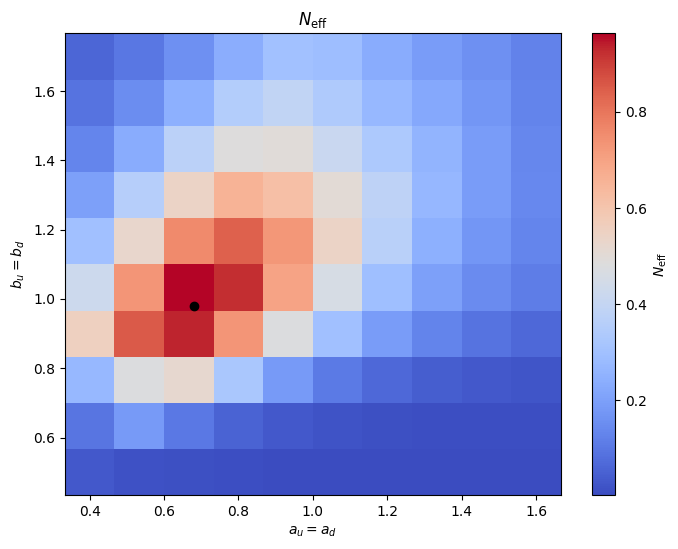

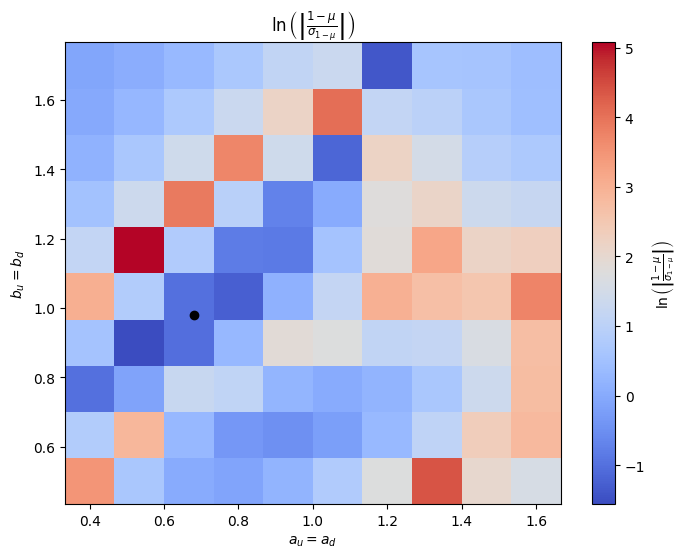

In [116]:



# Create the grid plot
plt.figure(figsize=(8, 6))
c = plt.pcolormesh(A_loaded, B_loaded, Neffs_loaded, cmap='coolwarm', shading='auto')  # Blocky representation
plt.scatter(0.68, 0.98, c='black')

# Add colorbar
plt.colorbar(c, label=r"$N_{\mathrm{eff}}$")  

# Labels and title
plt.xlabel(r"$a_u = a_d$")
plt.ylabel(r"$b_u = b_d$")
plt.title(r"$N_{\mathrm{eff}}$")

# Show the plot
plt.show()

# Create the grid plot
plt.figure(figsize=(8, 6))
c = plt.pcolormesh(A_loaded, B_loaded, Sigmas_loaded, cmap='coolwarm', shading='auto')  # Blocky representation
plt.scatter(0.68, 0.98, c='black')
# Add colorbar
sig_label = r"$\ln \left( \left| \frac{1 - \mu}{\sigma_{1 - \mu}} \right| \right)$"

plt.colorbar(c, label=sig_label)  

# Labels and title
plt.xlabel(r"$a_u = a_d$")
plt.ylabel(r"$b_u = b_d$")
plt.title(sig_label)

# Show the plot
plt.show()




In [7]:
grid_res = 10

ad_range = np.linspace(0.4,1.6, grid_res)
au_range = np.linspace(0.4,1.6, grid_res)
b_range = np.linspace(0.5,1.7, grid_res)

# print(a_range,b_range)

# print(np.meshgrid(a_range,b_range))
Ad,Au,B = np.meshgrid(ad_range,au_range,b_range)
W = []
Neffs = np.zeros_like(Ad)
Sigmas = np.zeros_like(Ad)

# nevents = 100

for iad in range(Ad.shape[0]):
    print(iad)
    for iau in range(Ad.shape[1]):
        print(iau)
        for ib in range(Ad.shape[2]):

            # Set base (reference) parameterization
            # aLundD = 0.61
            # bLundD = 1.0
            # aLundU = 0.78
            # bLundU = 0.88
            # aLundS = 0.48
            # bLundS = 1.0
            # aLundDiquark = 1.65
            # bLundDiquark = 1.2

            aExtraDQuark = 0
            aExtraUQuark = 0
            aExtraSQuark = 0
            aExtraCquark = 0
            aExtraBquark = 0
            aExtraDiquark = 0.97

            bNonstandardD = 0.88
            bNonstandardU = 0.88
            bNonstandardS = 0.88
            bNonstandardC = 0.88
            bNonstandardB = 0.88
            bNonstandardH = 0.88

            aLund = 0.68
            bLund = 0.98

            aLundD = aLund + aExtraDQuark
            # bLundD = bNonstandardD
            bLundD = bLund
            aLundU = aLund + aExtraUQuark
            # bLundU = bNonstandardU
            bLundU = bLund
            aLundS = aLund + aExtraSQuark
            # bLundS = bNonstandardS
            bLundS = bLund
            aLundDiquark = aLund + aExtraDiquark
            # bLundDiquark = bNonstandardH
            bLundDiquark = bLund


            params_base = {'a0': torch.tensor(0.0), 'b0': torch.tensor(0.0),
                        'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU), 'b2': torch.tensor(bLundU),
                        'a3': torch.tensor(aLundS), 'b3': torch.tensor(bLundS), 'a1103': torch.tensor(aLundDiquark), 'b1103': torch.tensor(bLundDiquark),
                        'a2101': torch.tensor(aLundDiquark), 'b2101': torch.tensor(bLundDiquark), 'a2103': torch.tensor(aLundDiquark), 'b2103': torch.tensor(bLundDiquark),
                        'a2203': torch.tensor(aLundDiquark), 'b2203': torch.tensor(bLundDiquark), 'a3101': torch.tensor(aLundDiquark), 'b3101': torch.tensor(bLundDiquark),
                        'a3103': torch.tensor(aLundDiquark), 'b3103': torch.tensor(bLundDiquark), 'a3201': torch.tensor(aLundDiquark), 'b3201': torch.tensor(bLundDiquark),
                        'a3203': torch.tensor(aLundDiquark), 'b3203': torch.tensor(bLundDiquark), 'a3303': torch.tensor(aLundDiquark), 'b3303': torch.tensor(bLundDiquark)}

            # Set parameters to reweigh to (alternative parameterization)
            # Technically should only include the parameters that are being reweighted
            #aLundD_alt = 0.61
            # bLundD_alt = 0.85 # Target v1
            # aLundU_alt = 0.73 # Target v1
            # bLundU_alt = 0.7  # Target v1

            aLund_target = 0.68
            bLund_target = 0.98

            aLundU_alt = Au[iad,iau,ib]
            aLundD_alt = Ad[iad,iau,ib]
            bLundU_alt = B[iad,iau,ib]
            bLundD_alt = B[iad,iau,ib]

            # aLundU_alt = 0.76
            # aLundD_alt = 0.76
            # bLundU_alt = 0.84
            # bLundD_alt = 0.84

            #bLundD_alt = 0.93 # Target v2
            #aLundU_alt = 0.75 # Target v2
            #bLundU_alt = 0.95  # Target v2
            #aLundS_alt = 0.48
            #bLundS_alt = 1.1
            #aLundDiquark_alt = 1.65
            #bLundDiquark_alt = 1.2
            params_alt = {#'a0': torch.tensor(0.0), 'b0': torch.tensor(0.0),
                        'a1': torch.tensor(aLundD_alt), 
                        'a2': torch.tensor(aLundU_alt),
                        'b1': torch.tensor(bLundD_alt),  
                        'b2': torch.tensor(bLundU_alt)}
                        #'b3': torch.tensor(bLundS_alt)}
                        #'a3': torch.tensor(aLundS_alt), , 'a1103': torch.tensor(aLundDiquark_alt), 'b1103': torch.tensor(bLundDiquark_alt),
                        #'a2101': torch.tensor(aLundDiquark_alt), 'b2101': torch.tensor(bLundDiquark_alt), 'a2103': torch.tensor(aLundDiquark_alt), 'b2103': torch.tensor(bLundDiquark_alt),
                        #'a2203': torch.tensor(aLundDiquark_alt), 'b2203': torch.tensor(bLundDiquark_alt), 'a3101': torch.tensor(aLundDiquark_alt), 'b3101': torch.tensor(bLundDiquark_alt),
                        #'a3103': torch.tensor(aLundDiquark_alt), 'b3103': torch.tensor(bLundDiquark_alt), 'a3201': torch.tensor(aLundDiquark_alt), 'b3201': torch.tensor(bLundDiquark_alt),
                        #'a3203': torch.tensor(aLundDiquark_alt), 'b3203': torch.tensor(bLundDiquark_alt), 'a3303': torch.tensor(aLundDiquark_alt), 'b3303': torch.tensor(bLundDiquark_alt)}

            # Set the over sample factor (for the pgun_qqbar datasets this is 10.)
            over_sample_factor = 10.

            # print(params_alt)
            # Initialize the reweighting module
            reweighter = LundWeight(params_base, params_alt, over_sample_factor = over_sample_factor)


            # Target
            pgun_accept_reject_base_torch = torch.from_numpy(pgun_accept_reject_base[0:nevents].copy())
            pgun_fPrel_base_torch = torch.from_numpy(pgun_fPrel_base[0:nevents].copy())

            weights = reweighter.forward(pgun_accept_reject_base_torch, pgun_fPrel_base_torch)
            weights = weights.detach().numpy()
            # Wtemp.append(weights)
            one_minus_mu = 1. - np.sum(weights) / len(weights)
            sigma_one_minus_mu = abs(1. - np.sqrt((np.sum(weights**2)/len(weights) - (np.sum(weights)/len(weights))**2)*len(weights)/(len(weights) - 1)))/np.sqrt(len(weights))
            Neff = (np.sum(weights)**2 / np.sum(weights**2)) / len(weights)
            Neffs[iad,iau,ib] = Neff
            Sigmas[iad,iau,ib] = np.log(np.abs(one_minus_mu/sigma_one_minus_mu))
        # W.append(Wtemp)





0
0
1
2
3
4
5
6
7
8
9
1
0
1
2
3
4
5
6
7
8
9
2
0
1
2
3
4
5
6
7
8
9
3
0
1
2
3
4
5
6
7
8
9
4
0
1
2
3
4
5
6
7
8
9
5
0
1
2
3
4
5
6
7
8
9
6
0
1
2
3
4
5
6
7
8
9
7
0
1
2
3
4
5
6
7
8
9
8
0
1
2
3
4
5
6
7
8
9
9
0
1
2
3
4
5
6
7
8
9


In [3]:
# Saving files
nevents = 1000
# print(nevents)
Neffs_file_name = f'Neffs_3d1_N{nevents}'
Sigma_file_name = 'Sigmas_3d1_N{nevents}'
A_file_name = 'Ad_3d1_N{nevents}'
B_file_name = 'B_3d1_N{nevents}'
C_file_name = 'Au_3d1_N{nevents}'


# np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + Neffs_file_name, Neffs)
# np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + Sigma_file_name, Sigmas)
# np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + A_file_name, Ad)
# np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + B_file_name, B)
# np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + C_file_name, Au)

# Loading the saved files into variables with '_loaded' suffix
Neffs_loaded = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + Neffs_file_name + '.npy')
Sigmas_loaded = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + Sigma_file_name + '.npy')
Ad_loaded = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + A_file_name + '.npy')
B_loaded = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + B_file_name + '.npy')
Au_loaded = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Metrics/' + C_file_name + '.npy')



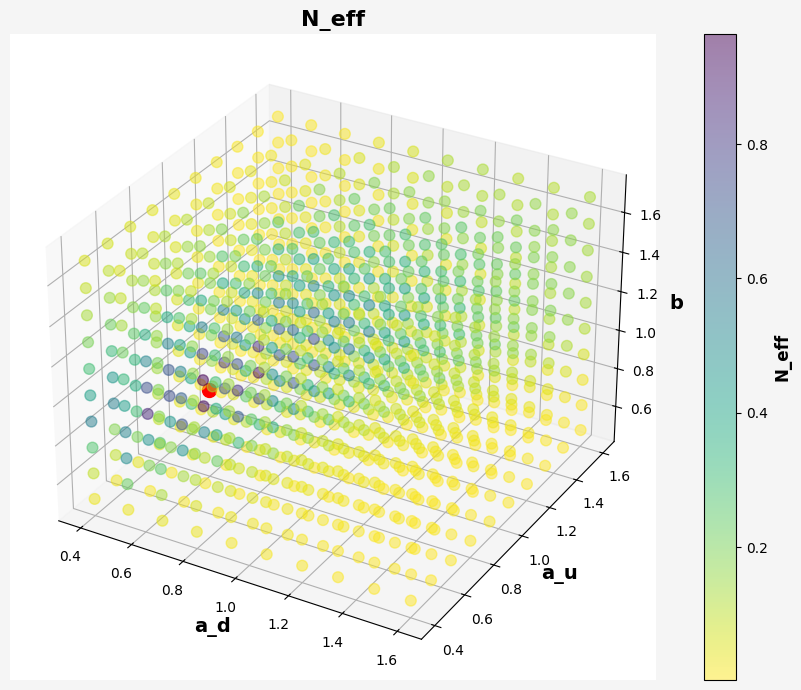

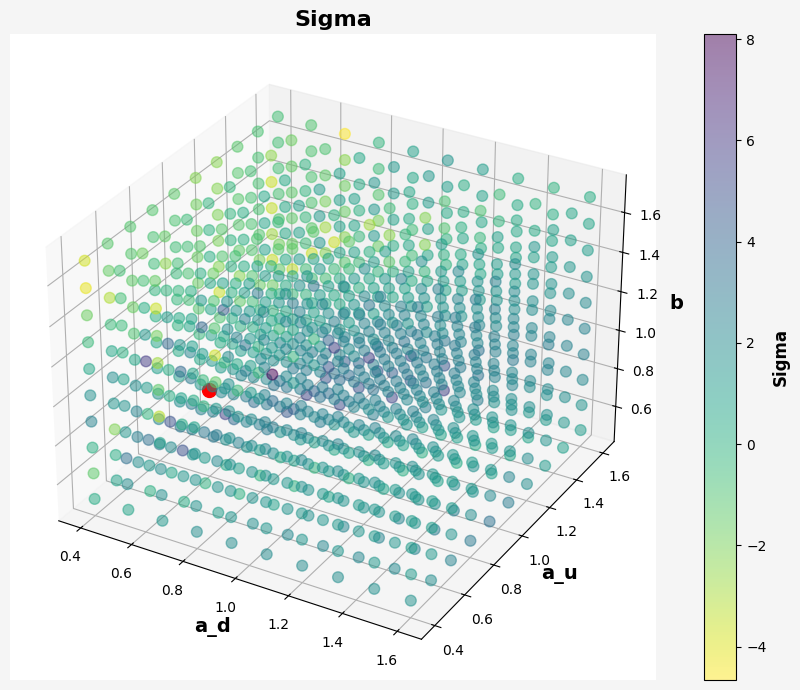

In [6]:
# Assuming the variables Ad_loaded, Au_loaded, B_loaded, and Neffs_loaded are already defined and loaded with data
# Flatten the grids and function values for plotting
x_vals = Ad_loaded.flatten()
y_vals = Au_loaded.flatten()
z_vals = B_loaded.flatten()
N_eff = Neffs_loaded.flatten()

# Create the 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with a color map
scat = ax.scatter(x_vals, y_vals, z_vals, c=N_eff, cmap='viridis_r', s=60, alpha=0.5)
ax.scatter(0.68,0.68,0.98, s=100, c='red')

# Labels and title with larger font size and bold styling
ax.set_xlabel('a_d', fontsize=14, fontweight='bold')
ax.set_ylabel('a_u', fontsize=14, fontweight='bold')
ax.set_zlabel('b', fontsize=14, fontweight='bold')
ax.set_title('N_eff', fontsize=16, fontweight='bold')

# Add a colorbar with improved style
colorbar = fig.colorbar(scat)
colorbar.set_label('N_eff', fontsize=12, fontweight='bold')
colorbar.ax.tick_params(labelsize=10)

# Improve layout and tight layout
plt.tight_layout()

# Set background color for a softer look
fig.patch.set_facecolor('whitesmoke')
ax.set_facecolor('white')

# Adding grid for better visibility
ax.grid(True, linestyle='--', color='gray', alpha=0.6)

plt.show()

# Assuming the variables Ad_loaded, Au_loaded, B_loaded, and Neffs_loaded are already defined and loaded with data
# Flatten the grids and function values for plotting
x_vals = Ad_loaded.flatten()
y_vals = Au_loaded.flatten()
z_vals = B_loaded.flatten()
Sigmas = Sigmas_loaded.flatten()

# Create the 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with a color map
scat = ax.scatter(x_vals, y_vals, z_vals, c=Sigmas, cmap='viridis_r', s=60, alpha=0.5)
ax.scatter(0.68,0.68,0.98, s=100, c='red')

# Labels and title with larger font size and bold styling
ax.set_xlabel('a_d', fontsize=14, fontweight='bold')
ax.set_ylabel('a_u', fontsize=14, fontweight='bold')
ax.set_zlabel('b', fontsize=14, fontweight='bold')
ax.set_title('Sigma', fontsize=16, fontweight='bold')

# Add a colorbar with improved style
colorbar = fig.colorbar(scat)
colorbar.set_label('Sigma', fontsize=12, fontweight='bold')
colorbar.ax.tick_params(labelsize=10)

# Improve layout and tight layout
plt.tight_layout()

# Set background color for a softer look
fig.patch.set_facecolor('whitesmoke')
ax.set_facecolor('white')

# Adding grid for better visibility
ax.grid(True, linestyle='--', color='gray', alpha=0.6)

plt.show()